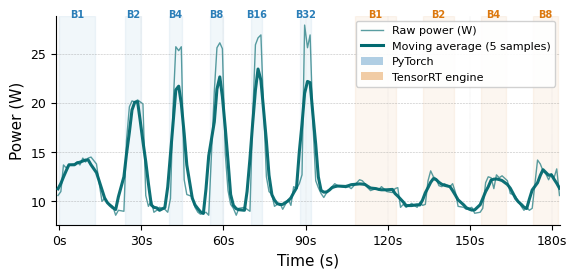

PDF : /home/paco/Proyectos/WAID/plots/power_inference.pdf
PNG : /home/paco/Proyectos/WAID/plots/power_inference.png
Muestras  : 163
Ventana   : 184.0 s
μ         : 12.68 W
σ         : 4.66 W
Rango     : [8.6, 27.9] W


In [8]:
#!/usr/bin/env python3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from pathlib import Path

# ── Rutas ──────────────────────────────────────────────────────────────────
DEVICE = "Jetson"

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

ROOT_DIR   = BASE_DIR.parent
DEVICE_DIR = ROOT_DIR / "logs" / DEVICE
PLOTS_DIR  = ROOT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

POWER_CSV  = DEVICE_DIR / "history_batch_inference.csv"
BENCH_CSV  = DEVICE_DIR / "WAIDplus_batch_inference_times.csv"
OUTPUT_PDF = PLOTS_DIR  / "power_inference.pdf"
OUTPUT_PNG = PLOTS_DIR  / "power_inference.png"

# ── Configuración ──────────────────────────────────────────────────────────
BLOCKS_TZ   = "Europe/Madrid"
ROLL_WINDOW = 5
DOWNSAMPLE  = 1

# Mismos colores que el script de training
COLOR_RAW    = "#01696f"
COLOR_SMOOTH = "#01696f"

# Colores de los bloques (PT vs Engine) — más suaves
COLOR_PT     = "#1f77b4"
COLOR_ENG    = "#da7101"

# Transparencias y grosores
ALPHA_BLOCKS = 0.06   # ↓↓ bloques muy suaves
ALPHA_RAW    = 0.65   # ↑↑ raw bien visible
LW_RAW       = 1    # ↑↑ raw más grueso
LW_SMOOTH    = 2.2

# ── Carga power ────────────────────────────────────────────────────────────
df_power = pd.read_csv(POWER_CSV)
df_power["timestamp"] = pd.to_datetime(df_power["last_changed"], utc=True)
df_power["power_W"]   = pd.to_numeric(df_power["state"], errors="coerce")
df_power = (df_power
            .dropna(subset=["power_W"])
            .sort_values("timestamp")
            .reset_index(drop=True))

# ── Carga benchmark ────────────────────────────────────────────────────────
df_bench = pd.read_csv(BENCH_CSV)
df_bench["Tiempo_total_s"] = pd.to_numeric(df_bench["Tiempo_total_s"], errors="coerce")
df_bench = df_bench.dropna(subset=["Tiempo_total_s"]).copy()

df_bench["t_ini"] = (pd.to_datetime(df_bench["Inicio"])
                       .dt.tz_localize(BLOCKS_TZ).dt.tz_convert("UTC"))
df_bench["t_fin"] = (pd.to_datetime(df_bench["Fin"])
                       .dt.tz_localize(BLOCKS_TZ).dt.tz_convert("UTC"))

# ── Tiempo relativo en segundos desde el primer bench ──────────────────────
t0 = df_bench["t_ini"].iloc[0]
df_power["t_s"]      = (df_power["timestamp"] - t0).dt.total_seconds()
df_bench["t_s_ini"]  = (df_bench["t_ini"] - t0).dt.total_seconds()
df_bench["t_s_fin"]  = (df_bench["t_fin"] - t0).dt.total_seconds()

# ── Ventana de la gráfica: 1s antes del primer bench, 1s después del último
t_view_min = df_bench["t_s_ini"].min() - 1
t_view_max = df_bench["t_s_fin"].max() + 1

# ── Media móvil ────────────────────────────────────────────────────────────
df_power["power_smooth"] = (df_power["power_W"]
                             .rolling(window=ROLL_WINDOW, center=True, min_periods=1)
                             .mean())

# ── Recortar a la ventana de interés ───────────────────────────────────────
mask = (df_power["t_s"] >= t_view_min) & (df_power["t_s"] <= t_view_max)
df_plot = df_power[mask].iloc[::DOWNSAMPLE].copy()

# ── Figura ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Sombrear ventanas de inferencia (PT vs Engine) — bloques suaves
for _, r in df_bench.iterrows():
    color = COLOR_PT if r["Formato"] == "pt" else COLOR_ENG
    ax.axvspan(r["t_s_ini"], r["t_s_fin"], alpha=ALPHA_BLOCKS, color=color, zorder=1)
    # Etiqueta de batch
    midpoint = (r["t_s_ini"] + r["t_s_fin"]) / 2
    ax.text(midpoint, df_plot["power_W"].max() * 1.02,
            f'B{int(r["Batch_size"])}',
            fontsize=7, ha="center", va="bottom",
            color=color, alpha=0.95, fontweight="bold")

# Señal raw — más visible
ax.plot(df_plot["t_s"], df_plot["power_W"],
        color=COLOR_RAW, linewidth=LW_RAW, alpha=ALPHA_RAW,
        label="Raw power (W)", zorder=1)

# Media móvil
ax.plot(df_plot["t_s"], df_plot["power_smooth"],
        color=COLOR_SMOOTH, linewidth=LW_SMOOTH, alpha=0.95,
        label=f"Moving average ({ROLL_WINDOW} samples)", zorder=3)

# ── Eje X en segundos ─────────────────────────────────────────────────────
ax.set_xlim(left=t_view_min, right=t_view_max)
ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}s"))

# Etiquetas
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Power (W)", fontsize=11)
ax.tick_params(axis="x", rotation=0, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="y", linestyle="--", linewidth=0.4, alpha=0.5, color="gray")
ax.grid(axis="x", linestyle=":",  linewidth=0.3, alpha=0.4, color="gray")

# ── Leyenda ────────────────────────────────────────────────────────────────
legend_handles = [
    plt.Line2D([0], [0], color=COLOR_RAW, lw=LW_RAW, alpha=ALPHA_RAW,
               label="Raw power (W)"),
    plt.Line2D([0], [0], color=COLOR_SMOOTH, lw=LW_SMOOTH,
               label=f"Moving average ({ROLL_WINDOW} samples)"),
    Patch(facecolor=COLOR_PT, alpha=0.35, label="PyTorch"),
    Patch(facecolor=COLOR_ENG, alpha=0.35, label="TensorRT engine"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="upper right",
          framealpha=0.9, edgecolor="#cccccc")

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUTPUT_PDF, bbox_inches="tight", facecolor="white")
fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

# ── Estadísticas ───────────────────────────────────────────────────────────
p_mean = df_power.loc[mask, "power_W"].mean()
p_std  = df_power.loc[mask, "power_W"].std()
p_min  = df_power.loc[mask, "power_W"].min()
p_max  = df_power.loc[mask, "power_W"].max()
print(f"PDF : {OUTPUT_PDF}")
print(f"PNG : {OUTPUT_PNG}")
print(f"Muestras  : {mask.sum()}")
print(f"Ventana   : {t_view_max - t_view_min:.1f} s")
print(f"μ         : {p_mean:.2f} W")
print(f"σ         : {p_std:.2f} W")
print(f"Rango     : [{p_min:.1f}, {p_max:.1f}] W")

Idle baseline: 10.40 W
Formato  Batch_size  Latencia_ms  J_por_imagen
     pt           1       33.480      0.096624
     pt           2       16.379      0.119776
     pt           4       11.213      0.121168
     pt           8       11.123      0.111879
     pt          16       11.083      0.115146
     pt          32       10.395      0.107850
 engine           1       38.257      0.031542
 engine           2       27.601      0.039063
 engine           4       23.572      0.031009
 engine           8       21.901      0.046748


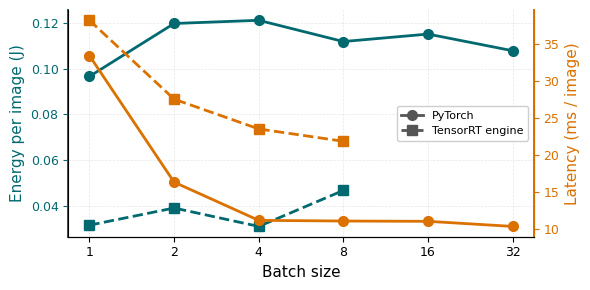

PDF : /home/paco/Proyectos/WAID/plots/latency_energy_vs_batch.pdf
PNG : /home/paco/Proyectos/WAID/plots/latency_energy_vs_batch.png


In [12]:
#!/usr/bin/env python3
"""
Gráfica: Energía/imagen (eje Y izq, verde) y Latencia (eje Y der, dorado)
en función del batch size. Compara PT y Engine.

Estilo:
  - Eje izquierdo (Energía):   verde  #01696f
      · PT     -> continuo, marcador círculo
      · Engine -> discontinuo, marcador cuadrado
  - Eje derecho (Latencia):    dorado #da7101
      · PT     -> continuo, marcador círculo
      · Engine -> discontinuo, marcador cuadrado
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ── Rutas ──────────────────────────────────────────────────────────────────
DEVICE = "Jetson"

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

ROOT_DIR   = BASE_DIR.parent
DEVICE_DIR = ROOT_DIR / "logs" / DEVICE
PLOTS_DIR  = ROOT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

POWER_CSV  = DEVICE_DIR / "history_batch_inference.csv"
BENCH_CSV  = DEVICE_DIR / "WAIDplus_batch_inference_times.csv"
OUTPUT_PDF = PLOTS_DIR  / "latency_energy_vs_batch.pdf"
OUTPUT_PNG = PLOTS_DIR  / "latency_energy_vs_batch.png"

# ── Estilo ─────────────────────────────────────────────────────────────────
BLOCKS_TZ = "Europe/Madrid"

COLOR_ENERGY  = "#01696f"   # verde — eje izquierdo
COLOR_LATENCY = "#da7101"   # dorado — eje derecho

LW    = 2
MS    = 7     # markersize

# Trapecio: numpy >=2 usa np.trapezoid, antes np.trapz
_trap = getattr(np, "trapezoid", np.trapz)

# ── Carga power ────────────────────────────────────────────────────────────
df_power = pd.read_csv(POWER_CSV)
df_power["timestamp"] = pd.to_datetime(df_power["last_changed"], utc=True)
df_power["power_W"]   = pd.to_numeric(df_power["state"], errors="coerce")
df_power = (df_power
            .dropna(subset=["power_W"])
            .sort_values("timestamp")
            .reset_index(drop=True))

# ── Carga benchmark ────────────────────────────────────────────────────────
df_bench = pd.read_csv(BENCH_CSV)
df_bench["Tiempo_total_s"]     = pd.to_numeric(df_bench["Tiempo_total_s"], errors="coerce")
df_bench["Tiempo_medio_img_s"] = pd.to_numeric(df_bench["Tiempo_medio_img_s"], errors="coerce")
df_bench["Num_imgs"]           = pd.to_numeric(df_bench["Num_imgs"], errors="coerce")
df_bench = df_bench.dropna(subset=["Tiempo_total_s"]).copy()

df_bench["t_ini"] = (pd.to_datetime(df_bench["Inicio"])
                       .dt.tz_localize(BLOCKS_TZ).dt.tz_convert("UTC"))
df_bench["t_fin"] = (pd.to_datetime(df_bench["Fin"])
                       .dt.tz_localize(BLOCKS_TZ).dt.tz_convert("UTC"))

# ── Baseline idle ──────────────────────────────────────────────────────────
t_first = df_bench["t_ini"].min()
baseline_W = df_power.loc[df_power["timestamp"] < t_first, "power_W"].median()
if np.isnan(baseline_W):
    baseline_W = df_power["power_W"].quantile(0.10)
print(f"Idle baseline: {baseline_W:.2f} W")

# ── Energía por fila ───────────────────────────────────────────────────────
def energia_neta_J(t0, t1, baseline):
    m = (df_power["timestamp"] >= t0) & (df_power["timestamp"] <= t1)
    sub = df_power.loc[m]
    if len(sub) < 2:
        return np.nan
    t = sub["timestamp"].astype("int64").to_numpy() / 1e9
    p = np.clip(sub["power_W"].to_numpy() - baseline, 0, None)
    return _trap(p, t)

df_bench["Energia_J_neta"] = df_bench.apply(
    lambda r: energia_neta_J(r["t_ini"], r["t_fin"], baseline_W), axis=1
)
df_bench["J_por_imagen"] = df_bench["Energia_J_neta"] / df_bench["Num_imgs"]
df_bench["Latencia_ms"]  = df_bench["Tiempo_medio_img_s"] * 1000

print(df_bench[["Formato","Batch_size","Latencia_ms","J_por_imagen"]].to_string(index=False))

# ── Figura ─────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(6, 3))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")
ax1.spines["top"].set_visible(False)

# ─── EJE IZQUIERDO: ENERGÍA (verde) ────────────────────────────────────────
# PT: continuo + círculo
sub_pt = df_bench[df_bench["Formato"] == "pt"].sort_values("Batch_size")
ax1.plot(sub_pt["Batch_size"], sub_pt["J_por_imagen"],
         color=COLOR_ENERGY, linewidth=LW,
         linestyle="-", marker="o", markersize=MS,
         markerfacecolor=COLOR_ENERGY, markeredgecolor=COLOR_ENERGY)

# Engine: discontinuo + cuadrado
sub_en = df_bench[df_bench["Formato"] == "engine"].sort_values("Batch_size")
ax1.plot(sub_en["Batch_size"], sub_en["J_por_imagen"],
         color=COLOR_ENERGY, linewidth=LW,
         linestyle="--", marker="s", markersize=MS,
         markerfacecolor=COLOR_ENERGY, markeredgecolor=COLOR_ENERGY)

ax1.set_xlabel("Batch size", fontsize=11)
ax1.set_ylabel("Energy per image (J)", fontsize=11, color=COLOR_ENERGY)
ax1.tick_params(axis="y", labelsize=9, colors=COLOR_ENERGY)
ax1.spines["left"].set_color(COLOR_ENERGY)
ax1.spines["left"].set_linewidth(1.4)

# Eje X log base 2
ax1.set_xscale("log", base=2)
xt = sorted(df_bench["Batch_size"].unique())
ax1.set_xticks(xt)
ax1.set_xticklabels(xt)
ax1.tick_params(axis="x", labelsize=9)
ax1.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

# ─── EJE DERECHO: LATENCIA (dorado) ────────────────────────────────────────
ax2 = ax1.twinx()
ax2.spines["top"].set_visible(False)

# PT: continuo + círculo
ax2.plot(sub_pt["Batch_size"], sub_pt["Latencia_ms"],
         color=COLOR_LATENCY, linewidth=LW,
         linestyle="-", marker="o", markersize=MS,
         markerfacecolor=COLOR_LATENCY, markeredgecolor=COLOR_LATENCY)

# Engine: discontinuo + cuadrado
ax2.plot(sub_en["Batch_size"], sub_en["Latencia_ms"],
         color=COLOR_LATENCY, linewidth=LW,
         linestyle="--", marker="s", markersize=MS,
         markerfacecolor=COLOR_LATENCY, markeredgecolor=COLOR_LATENCY)

ax2.set_ylabel("Latency (ms / image)", fontsize=11, color=COLOR_LATENCY)
ax2.tick_params(axis="y", labelsize=9, colors=COLOR_LATENCY)
ax2.spines["right"].set_color(COLOR_LATENCY)
ax2.spines["right"].set_linewidth(1.4)

# ── Leyenda: 4 entradas, agrupadas por estilo (PT continuo, Engine discontinuo)
legend_elements = [
    Line2D([0],[0], color="#555555", lw=LW, marker="o", markersize=MS,
           linestyle="-",  label="PyTorch"),
    Line2D([0],[0], color="#555555", lw=LW, marker="s", markersize=MS,
           linestyle="--", label="TensorRT engine"),
]
ax1.legend(handles=legend_elements, fontsize=8, loc="center right",
           framealpha=0.95, edgecolor="#cccccc", ncol=1)

plt.tight_layout()
fig.savefig(OUTPUT_PDF, bbox_inches="tight", facecolor="white")
fig.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

print(f"PDF : {OUTPUT_PDF}")
print(f"PNG : {OUTPUT_PNG}")